# # **Diabetes Prediction with Logistic Regression**

This notebook trains a **logistic** regression model on the Pima Indians Diabetes dataset to predict whether a patient is diabetic based on medical measurements.  
Steps covered:
- Load and inspect the dataset  
- Split data into training and test sets  
- Train a logistic regression classifier  
- Evaluate accuracy  
- Make a prediction for a single new patient

In [1]:
# core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# Warnings removal
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Load and explore data
file_loc = "diabetes.csv"
diabets_df = pd.read_csv(file_loc)
print(diabets_df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# Basic info about columns, types, and missing values
print(diabets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
# Dataset shape
print(f"Number of rows: {diabets_df.shape[0]}, Number of columns: {diabets_df.shape[1]}")

Number of rows: 768, Number of columns: 9


In [5]:
# Class distribution based on the target variable ('Outcome' column)
counts = diabets_df['Outcome'].value_counts()
print(counts)

Outcome
0    500
1    268
Name: count, dtype: int64


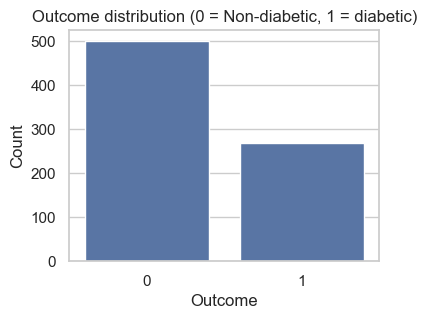

In [6]:
sns.set(style='whitegrid')
plt.figure(figsize=(4,3))
sns.countplot(x="Outcome", data=diabets_df)
plt.title("Outcome distribution (0 = Non-diabetic, 1 = diabetic)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

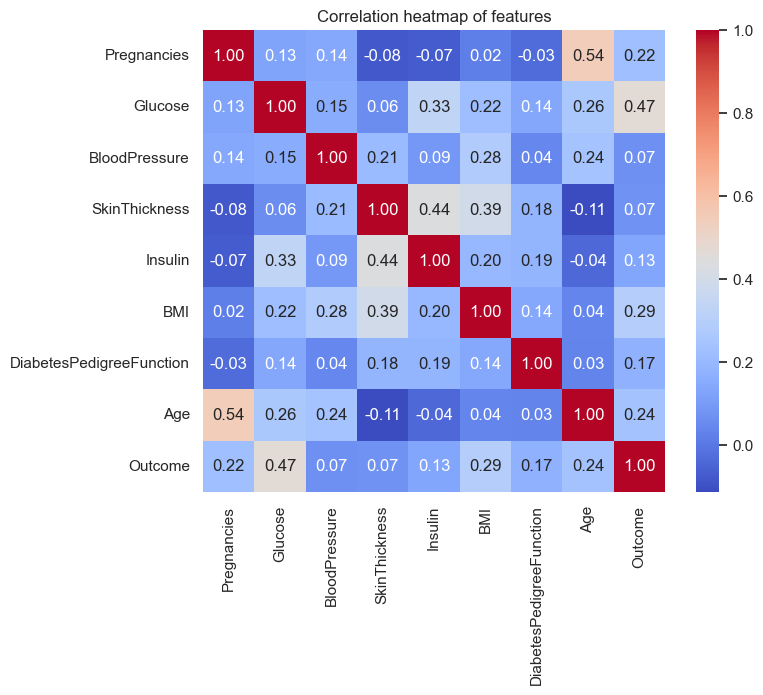

In [7]:
plt.figure(figsize=(8,6))
corr_heatmap = diabets_df.corr()
sns.heatmap(corr_heatmap, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title("Correlation heatmap of features")
plt.show()

## Train–test split and feature scaling

Features are separated from the target, then split into training and test sets with stratification to preserve class balance. 
Standardization is applied so logistic regression can converge more reliably.


In [10]:
# Separate features X and target Y
X = diabets_df.drop(columns = 'Outcome', axis = 1)
y = diabets_df['Outcome']


# Train–test split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1,
)

# Initialize the scalar and fit on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train logistic regression model

A logistic regression classifier is trained on the standardized features.
Afterwards, Model performance is evaluated using accuracy on the test set.


In [11]:
logistic_reg_model = LogisticRegression(max_iter=1000)
logistic_reg_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Make predictions on the test set
y_pred = logistic_reg_model.predict(X_test_scaled)

# Evaluation
model_accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy on Test data is: {model_accuracy:.4f}')

Accuracy on Test data is: 0.7857


## Predict for a new patient

A single patient's measurements are passed to the trained pipeline.  
The input is wrapped into a DataFrame with the same feature names as the training data to avoid feature-name warnings.


In [13]:
# ---- Evaluate model on external CSV of new patients -> randomly generated ----

# Path to the new patients file
new_patients_path = "new_patients_examples.csv"

# Load new patient data
new_patients = pd.read_csv(new_patients_path)

# Ensure column order matches the training data
new_patients = new_patients[X.columns]

# Scale using the previously fitted scaler
new_patients_scaled = scaler.transform(new_patients)

# Predict for all new patients
new_predictions = logistic_reg_model.predict(new_patients_scaled)
new_probabilities = logistic_reg_model.predict_proba(new_patients_scaled)[:, 1]

# Attach predictions back to the DataFrame
results_df = new_patients.copy()
results_df["PredictedOutcome"] = new_predictions
results_df["DiabetesProbability"] = new_probabilities

# Show first few rows
results_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,PredictedOutcome,DiabetesProbability
0,1,128,104,26,395,27.0,1.806,36,0,0.353639
1,9,99,92,48,601,27.4,1.151,19,0,0.172409
2,7,81,65,50,588,39.2,0.717,27,0,0.213259
3,5,142,107,23,423,35.8,0.286,77,0,0.476067
4,5,185,68,53,769,43.1,2.261,43,1,0.986727
